# MobileNetV2 Training Notebook

This notebook trains a MobileNetV2 classifier on the RealWaste dataset using the preprocessing pipeline in `src/preprocess.py`.

It keeps everything inside the notebook: data loading, training, evaluation, and plots.

In [7]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from tensorflow.keras import layers, Model, optimizers, losses
from tensorflow.keras.applications import MobileNetV2

possible_roots = [Path.cwd(), Path.cwd().parent]
for root in possible_roots:
    if (root / 'src').exists():
        REPO_ROOT = root
        break
else:
    REPO_ROOT = Path.cwd()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.preprocess import prepare_datasets

print('TensorFlow version:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))
print('CPUs:', tf.config.list_physical_devices('CPU'))

TensorFlow version: 2.20.0
GPUs: []
CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [8]:
# Config
DATA_DIR = str(REPO_ROOT / 'data' / 'RealWaste')
IMG_SIZE = 224
BATCH_SIZE = 8
TRAIN_EPOCHS = 50
FINE_TUNE_EPOCHS = 50
LR = 1e-3
FT_LR_SCALE = 0.01
DROPOUT = 0.2
UNFREEZE_LAYERS = 20

data = prepare_datasets(
    data_dir=DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    model_type='mobilenetv2',
)

train_ds = data['train_ds']
val_ds = data['val_ds']
test_ds = data['test_ds']
class_weights = data['class_weights']
class_names = data['class_names']
num_classes = len(class_names)

print('Classes:', class_names)
print('Num classes:', num_classes)
print('Data dir:', DATA_DIR)

Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Class counts: {'Cardboard': 461, 'Food Organics': 411, 'Glass': 420, 'Metal': 790, 'Miscellaneous Trash': 495, 'Paper': 500, 'Plastic': 921, 'Textile Trash': 318, 'Vegetation': 436}
Unreadable files: 0
Train: 3800 | Val: 476 | Test: 476
Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Num classes: 9
Data dir: /Users/luannguyen/PersonalProjects/garbage-material-classification/data/RealWaste


In [9]:
# Build the MobileNetV2 transfer-learning model
base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling='avg',
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.Dropout(DROPOUT)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Model Implementation Notes

- This notebook uses **MobileNetV2** with pretrained ImageNet weights as the base model for transfer learning.
- `include_top=False` removes the original ImageNet classifier, and `pooling='avg'` converts the convolutional output into one compact feature vector per image.
- The base model is frozen first with `base_model.trainable = False`, so phase 1 trains only the new classifier head.
- A `Dropout(0.2)` layer is added before the final dense layer to reduce overfitting.
- The output layer uses `Dense(num_classes, activation='softmax')`, which matches this 9-class image classification task.
- The loss function is `SparseCategoricalCrossentropy` because the labels are stored as integer class indices instead of one-hot vectors.


In [10]:
# Phase 1: feature extraction
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TRAIN_EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stopping]  # add this
)

Epoch 1/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 36s 67ms/step - accuracy: 0.4545 - loss: 1.5588 - val_accuracy: 0.6261 - val_loss: 0.9612
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.7251 - loss: 0.7205 - val_accuracy: 0.6975 - val_loss: 0.8507
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/step - accuracy: 0.7689 - loss: 0.6036 - val_accuracy: 0.7059 - val_loss: 0.8283
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 38s 74ms/step - accuracy: 0.7919 - loss: 0.5709 - val_accuracy: 0.7353 - val_loss: 0.7804
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - accuracy: 0.7992 - loss: 0.4980 - val_accuracy: 0.7353 - val_loss: 0.7315
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 43s 84ms/step - accuracy: 0.8127 - loss: 0.4889 - val_accuracy: 0.7521 - val_loss: 0.7396
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 43s 82ms/step - accuracy: 0.8324 - loss: 0.4508 - val_accuracy: 0.7458 - val_loss: 0.7422
Epoch 8/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - accuracy: 0.8264 - loss: 0.4262 - 

## Phase 1 Training Notes (Feature Extraction)

- Phase 1 trains only the classifier head while the MobileNetV2 backbone is frozen, using pretrained ImageNet features as a fixed feature extractor.

- Training accuracy increases steadily from ~0.45 to ~0.85, showing the classifier head is successfully learning to map extracted features to the 9 classes.

- Validation accuracy improves quickly early on (~0.62 → ~0.75), then plateaus around **0.74–0.76**, indicating the model reaches its limit with frozen features.

- Validation loss decreases initially (best ~0.68–0.73 range) but becomes unstable after ~epoch 6–10, suggesting mild overfitting in the classifier head.

- The gap between training accuracy (~0.85) and validation accuracy (~0.75) further supports slight overfitting, though not severe.

- `EarlyStopping` is important here, as it prevents unnecessary training once validation performance stops improving and restores the best weights.

- Overall, Phase 1 establishes a strong baseline, but performance saturation indicates that higher-level features need adaptation → motivating fine-tuning in Phase 2.

In [11]:
# Phase 2: fine-tuning
history2 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

if FINE_TUNE_EPOCHS > 0 and UNFREEZE_LAYERS > 0:
    base_model.trainable = True
    if UNFREEZE_LAYERS < len(base_model.layers):
        for layer in base_model.layers[:-UNFREEZE_LAYERS]:
            layer.trainable = False
        for layer in base_model.layers[-UNFREEZE_LAYERS:]:
            layer.trainable = True

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LR * FT_LR_SCALE),
        loss=losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy'],
    )

    early_stopping_ft = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history2_run = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINE_TUNE_EPOCHS,
        class_weight=class_weights,
        callbacks=[early_stopping_ft] 
    )

    history2 = history2_run.history
else:
    print('Fine-tuning skipped because FINE_TUNE_EPOCHS is 0.')

Epoch 1/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 53s 99ms/step - accuracy: 0.6360 - loss: 1.0261 - val_accuracy: 0.7290 - val_loss: 0.8537
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 50s 99ms/step - accuracy: 0.7283 - loss: 0.7294 - val_accuracy: 0.7290 - val_loss: 0.8951
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 51s 101ms/step - accuracy: 0.7447 - loss: 0.6795 - val_accuracy: 0.7269 - val_loss: 0.8806
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 51s 101ms/step - accuracy: 0.7673 - loss: 0.6267 - val_accuracy: 0.7206 - val_loss: 0.8587
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 52s 103ms/step - accuracy: 0.7585 - loss: 0.6446 - val_accuracy: 0.7122 - val_loss: 0.8413
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 58s 114ms/step - accuracy: 0.7965 - loss: 0.5462 - val_accuracy: 0.7164 - val_loss: 0.8224
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 52s 102ms/step - accuracy: 0.8119 - loss: 0.4929 - val_accuracy: 0.7269 - val_loss: 0.8153
Epoch 8/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 54s 104ms/step - accuracy: 0.8080 - loss: 0.5

## Fine-Tuning Notes (Phase 2)

- Phase 2 unfreezes the last portion of MobileNetV2, allowing higher-level pretrained features to adapt to the RealWaste dataset instead of remaining fixed.

- Training accuracy continues to increase significantly (~0.63 → >0.92), showing the model is learning more task-specific representations beyond the original ImageNet features.

- Validation accuracy improves more gradually (~0.73 → ~0.82–0.83), indicating that fine-tuning provides real generalization gains, not just memorization.

- Validation loss shows an overall downward trend (best ~0.59–0.62), confirming improved model confidence and better alignment with true labels.

- A small gap between training (~0.92+) and validation (~0.82) accuracy appears, suggesting moderate overfitting, but still within a reasonable range for this task.

- Early epochs show slight instability (validation fluctuations), which is expected after unfreezing since the optimization problem changes and more parameters become trainable.

- The reduced learning rate is critical here, ensuring pretrained weights are adjusted gradually rather than overwritten.

- Overall, fine-tuning is clearly beneficial: it improves both validation accuracy and loss compared to Phase 1, demonstrating successful adaptation of pretrained features to the domain-specific classification task.

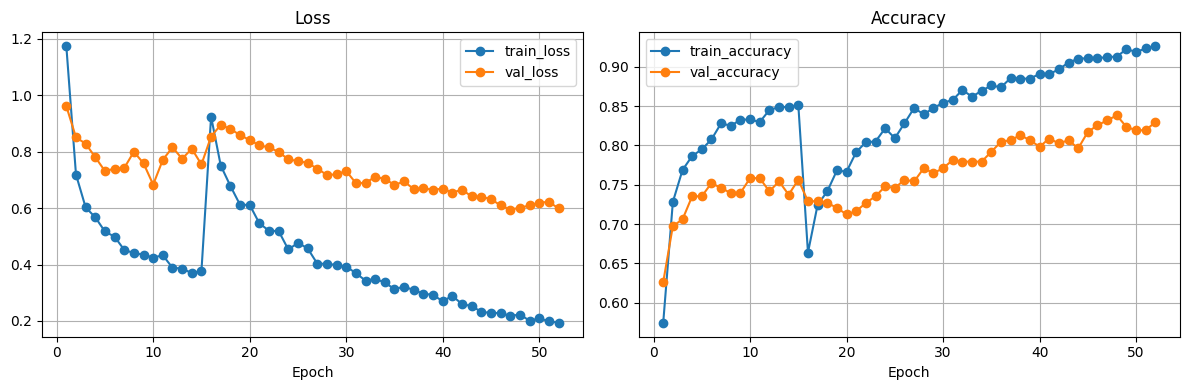

In [12]:
# Plot training curves inline
merged_history = {
    'loss': history1.history.get('loss', []) + history2.get('loss', []),
    'accuracy': history1.history.get('accuracy', []) + history2.get('accuracy', []),
    'val_loss': history1.history.get('val_loss', []) + history2.get('val_loss', []),
    'val_accuracy': history1.history.get('val_accuracy', []) + history2.get('val_accuracy', []),
}

epochs = list(range(1, len(merged_history['loss']) + 1))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, merged_history['loss'], marker='o', label='train_loss')
axes[0].plot(epochs, merged_history['val_loss'], marker='o', label='val_loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, merged_history['accuracy'], marker='o', label='train_accuracy')
axes[1].plot(epochs, merged_history['val_accuracy'], marker='o', label='val_accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

if len(epochs) == 1:
    for ax in axes:
        ax.set_xlim(0.5, 1.5)

plt.tight_layout()
plt.show()

## Training Curves Analysis (Loss & Accuracy)

- Training loss decreases steadily across epochs, indicating the model is continuously learning and fitting the training data more effectively.

- Validation loss drops early, then plateaus and slowly declines (~0.95 → ~0.60), showing improved generalization but at a slower rate than training.

- A noticeable spike in training loss and drop in accuracy around the mid-point corresponds to the transition into fine-tuning (unfreezing layers), which temporarily destabilizes optimization.

- After fine-tuning begins, both training and validation performance recover and improve, confirming successful adaptation of pretrained features.

- Training accuracy increases consistently (~0.57 → >0.92), while validation accuracy improves more gradually (~0.63 → ~0.82–0.83).

- The gap between training and validation curves indicates moderate overfitting, but not severe — the model still generalizes well.

- Validation curves remain relatively stable without sharp divergence, suggesting that regularization (dropout, augmentation, early stopping) is effective.

- Overall, the curves show:
  - Strong initial learning during feature extraction
  - Temporary instability during fine-tuning
  - Final convergence with improved generalization performance

In [13]:
# Final evaluation

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print('Test loss:', test_loss)
print('Test accuracy:', test_accuracy)
print('Macro precision:', precision_macro)
print('Macro recall:', recall_macro)
print('Macro F1:', f1_macro)
print('Weighted precision:', precision_weighted)
print('Weighted recall:', recall_weighted)
print('Weighted F1:', f1_weighted)
print('\nClassification report:\n')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

Test loss: 0.592928946018219
Test accuracy: 0.8298319578170776
Macro precision: 0.8356651098536126
Macro recall: 0.8315096845550589
Macro F1: 0.8285881468453832
Weighted precision: 0.8432142871950954
Weighted recall: 0.8298319327731093
Weighted F1: 0.8318729222228601

Classification report:

                     precision    recall  f1-score   support

          Cardboard       0.84      0.91      0.88        46
      Food Organics       0.97      0.73      0.83        41
              Glass       0.81      0.90      0.85        42
              Metal       0.90      0.84      0.87        79
Miscellaneous Trash       0.59      0.78      0.67        50
              Paper       0.79      0.84      0.82        50
            Plastic       0.90      0.78      0.84        92
      Textile Trash       0.82      0.72      0.77        32
         Vegetation       0.90      0.98      0.93        44

           accuracy                           0.83       476
          macro avg       0.84    

2026-05-03 00:38:04.604834: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Evaluation Notes

- The overall test result for this run is strong: **82.98% test accuracy** with **macro F1 about 0.829** and **weighted F1 about 0.832**. That means the model performs well across the 9 classes, not only on the biggest ones.
- The weighted F1 and macro F1 are close, which suggests the class imbalance is being handled reasonably well and the model is not relying only on the majority classes.
- The strongest classes in this run are **Vegetation (F1 0.93)**, **Cardboard (F1 0.88)**, **Metal (F1 0.87)**, **Glass (F1 0.85)**, and **Plastic (F1 0.84)**. These classes likely benefit from more distinctive visual patterns.
- **Miscellaneous Trash** is still the weakest class with **F1 0.67** and lower precision. That makes sense because it is a broad catch-all category with less consistent visual features.
- **Food Organics** has extremely high precision (**0.97**) but lower recall (**0.73**), which means predictions of that class are usually correct, but the model still misses some true Food Organics images.
- **Textile Trash** also has lower recall than the strongest classes, which suggests that some textile images are still being confused with other categories.
- Fine-tuning appears helpful in this run: the final test loss is **0.593**, the final test accuracy is above **0.82**, and the overall result is better than the weaker earlier run that stayed closer to the low-0.81 or upper-0.80 range.


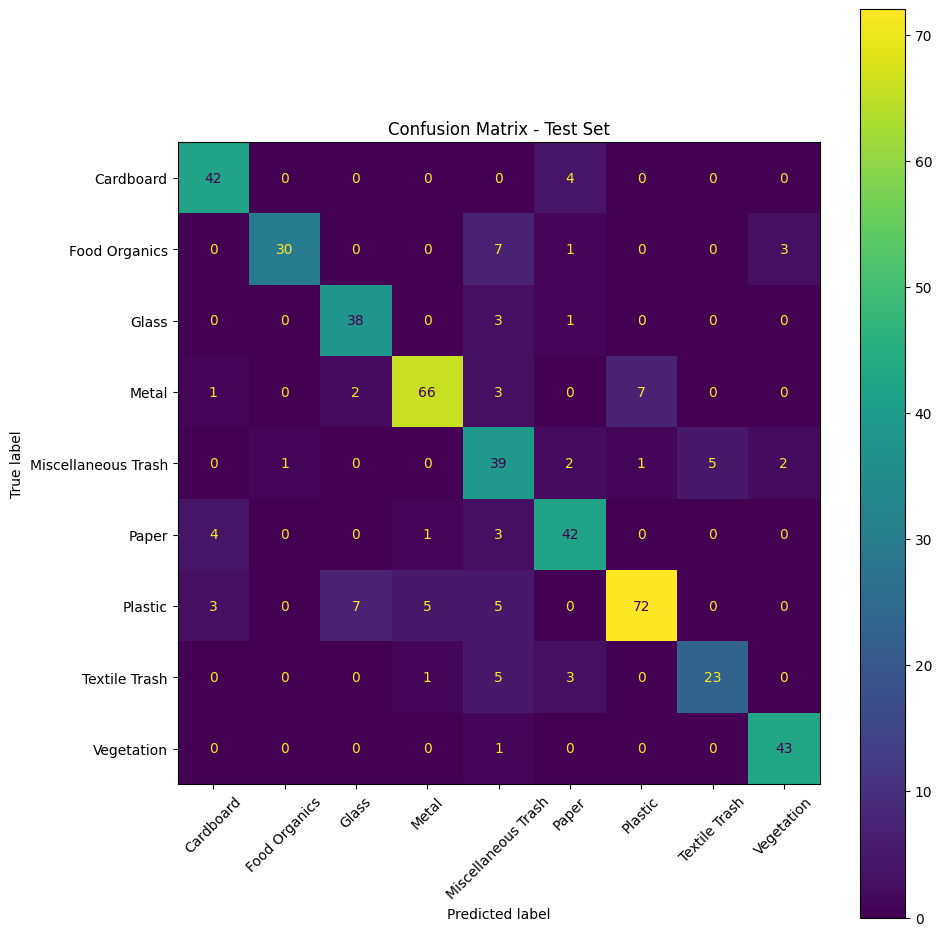

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

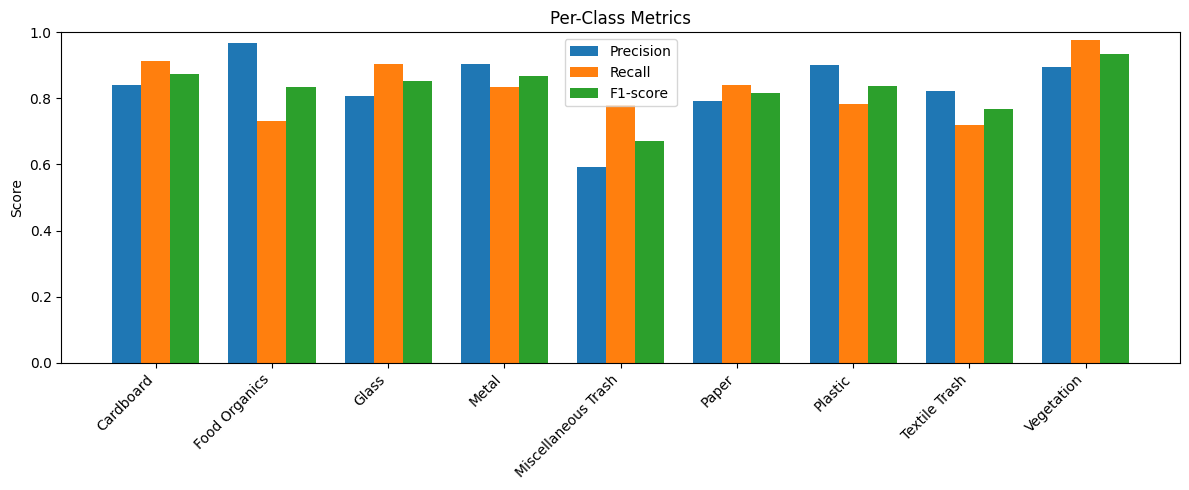

In [21]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

precisions = [report[c]['precision'] for c in class_names]
recalls = [report[c]['recall'] for c in class_names]
f1s = [report[c]['f1-score'] for c in class_names]

x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(12,5))
plt.bar(x - width, precisions, width, label='Precision')
plt.bar(x, recalls, width, label='Recall')
plt.bar(x + width, f1s, width, label='F1-score')

plt.xticks(x, class_names, rotation=45, ha='right')
plt.ylabel('Score')
plt.title('Per-Class Metrics')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

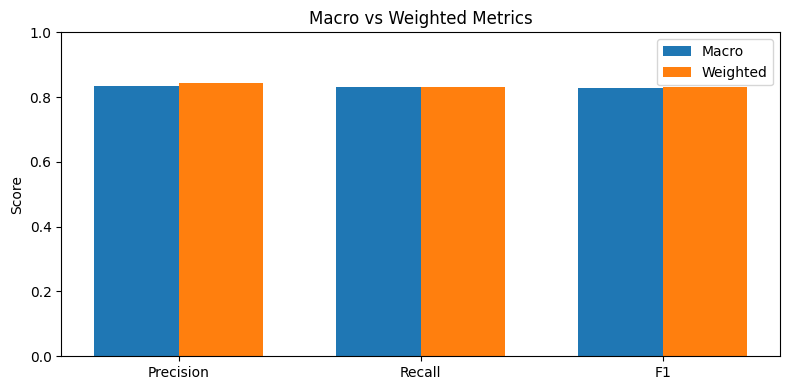

In [22]:
metrics = ['Precision', 'Recall', 'F1']
macro = [precision_macro, recall_macro, f1_macro]
weighted = [precision_weighted, recall_weighted, f1_weighted]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,4))
plt.bar(x - width/2, macro, width, label='Macro')
plt.bar(x + width/2, weighted, width, label='Weighted')

plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Macro vs Weighted Metrics')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

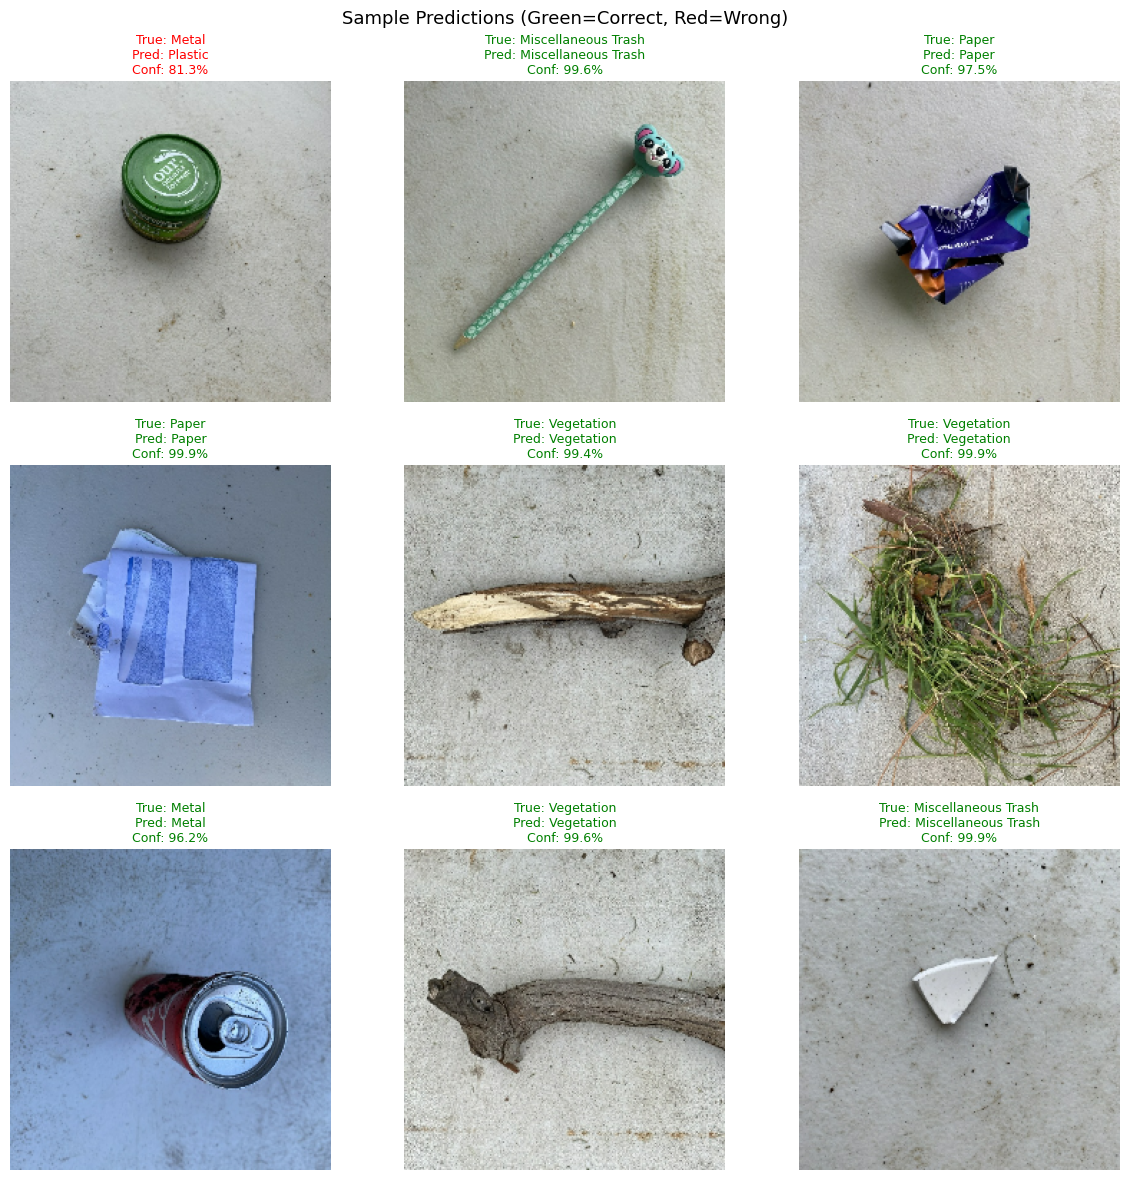

In [16]:
import math

def visualize_predictions(model, test_ds, class_names, num_examples=9):
    images_shown = []
    labels_shown = []
    
    for images, labels in test_ds:
        images_shown.append(images.numpy())
        labels_shown.append(labels.numpy())
        if sum(len(x) for x in images_shown) >= num_examples:
            break
    
    images_shown = np.concatenate(images_shown)[:num_examples]
    labels_shown = np.concatenate(labels_shown)[:num_examples]
    
    probs = model.predict(tf.constant(images_shown), verbose=0)  # softmax probabilities
    preds = np.argmax(probs, axis=1)
    confidences = np.max(probs, axis=1)  # ← highest probability = confidence
    
    cols = 3
    rows = math.ceil(num_examples / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.ravel()
    
    for i in range(num_examples):
        img = images_shown[i].copy()
        img = (img - img.min()) / (img.max() - img.min())
        
        axes[i].imshow(img)
        
        true_label = class_names[labels_shown[i]]
        pred_label = class_names[preds[i]]
        confidence = confidences[i] * 100  # convert to percentage
        correct = labels_shown[i] == preds[i]
        
        color = 'green' if correct else 'red'
        title = f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%"  # ← added
        axes[i].set_title(title, color=color, fontsize=9)
        axes[i].axis('off')
    
    for i in range(num_examples, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_ds, class_names, num_examples=9)